<a href="https://colab.research.google.com/github/shriyashshitole/simple-ARIMA/blob/main/ARIMAv1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import yfinance as yf
import pmdarima as pm
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
# ==========================================
# 1. USER SETTINGS
# ==========================================
TICKER = "AAPL"
PERIOD = "2y"
PREDICTION_DAYS = 30

print(f"1. Downloading data for {TICKER} over the last {PERIOD}...")

1. Downloading data for AAPL over the last 2y...


In [12]:
# ==========================================
# 2. GET THE DATA
# ==========================================
df = yf.download(TICKER, period=PERIOD, progress=False)

# Extract Close price
data = df['Close']

# Handle the table format (squeeze it to a list)
if isinstance(data, pd.DataFrame):
    data = data.squeeze()

# Remove timezone info to prevent plotting errors (make it "naive")
if data.index.tz is not None:
    data.index = data.index.tz_localize(None)

data = data.dropna()

print(f"   - Data loaded! Found {len(data)} days of trading data.")
print(f"   - Last known price: ${data.iloc[-1]:.2f}")

/tmp/ipython-input-3238413401.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, period=PERIOD, progress=False)


   - Data loaded! Found 503 days of trading data.
   - Last known price: $277.70


In [13]:
# ==========================================
# 3. TRAIN THE MODEL
# ==========================================
print("\n2. Finding the best ARIMA model...")

# We pass data.values to ensure the model focuses on the numbers, not the dates
# This prevents the index confusion warning
model = pm.auto_arima(data.values,
                      seasonal=False,
                      stepwise=True,
                      trace=True)

print("\n   - Best model found!")
print(model.summary())


2. Finding the best ARIMA model...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=2745.535, Time=0.63 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2746.554, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2745.452, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2745.883, Time=0.16 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2745.726, Time=0.02 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=2744.787, Time=0.12 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=2743.273, Time=0.14 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=2744.505, Time=0.23 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=2742.399, Time=0.45 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=2744.618, Time=0.37 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=2744.243, Time=0.60 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=1.24 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=2745.948, Time=2.13 sec
 ARIMA(3,1,1)(0,0,0)[0]             : AIC=2741.873, Time=0.61 sec
 A

In [14]:
# ==========================================
# 4. PREDICT THE FUTURE
# ==========================================
print(f"\n3. Forecasting the next {PREDICTION_DAYS} days...")

# Get forecast and confidence intervals
forecast, conf_int = model.predict(n_periods=PREDICTION_DAYS, return_conf_int=True)

# Generate future dates (Business days)
last_date = data.index[-1]
future_dates = pd.date_range(start=last_date, periods=PREDICTION_DAYS + 1, freq='B')[1:]

# --- THE FIX FOR THE NaN ERROR ---
# We force the forecast to be a simple list (.tolist()) before creating the Series.
# This prevents pandas from trying to align mismatched indices.
forecast_series = pd.Series(forecast.tolist(), index=future_dates)
lower_bound = pd.Series(conf_int[:, 0].tolist(), index=future_dates)
upper_bound = pd.Series(conf_int[:, 1].tolist(), index=future_dates)
# ---------------------------------


3. Forecasting the next 30 days...



4. Plotting the results...


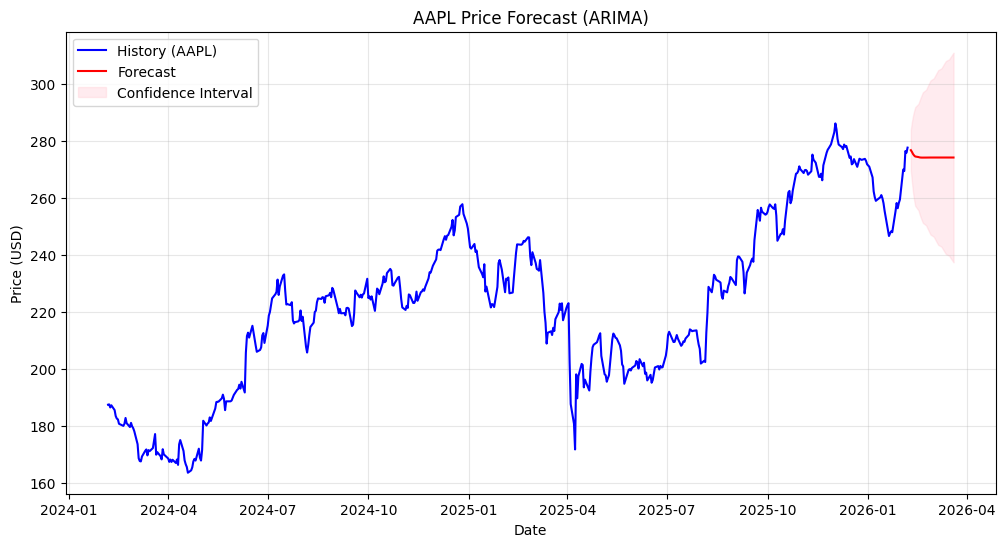

Predicted price in 30 days: $274.23


In [15]:
# ==========================================
# 5. VISUALIZE THE RESULTS
# ==========================================
print("\n4. Plotting the results...")

plt.figure(figsize=(12, 6))

# Plot History
plt.plot(data.index, data, label=f"History ({TICKER})", color='blue')

# Plot Forecast
plt.plot(forecast_series.index, forecast_series, label="Forecast", color='red')

# Plot Confidence Interval
plt.fill_between(lower_bound.index,
                 lower_bound,
                 upper_bound,
                 color='pink', alpha=0.3, label="Confidence Interval")

plt.title(f"{TICKER} Price Forecast (ARIMA)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Now this should print a real number!
print(f"Predicted price in {PREDICTION_DAYS} days: ${forecast_series.iloc[-1]:.2f}")